# Confronto sistematico degli ansatz per il trimero ad anello

Mirror diretto di `confronto_ansatz_entangler.ipynb` (dimero) e di
`confronto_ansatz_entangler_trimero_catena.ipynb` (catena aperta), stessa
metodologia (COBYLA + L-BFGS-B, 2 restart, fidelity contro il proiettore sul
fondamentale eventualmente degenere), applicata al trimero ad anello.

**Ricostruito da zero rispettando l'ordine corretto**: la domanda di design
"quale famiglia PMA regge meglio sotto DM, RBS o $W$?" è stata risolta
**prima**, in `analisi_espressivita_PMA_anello.ipynb` (mirror di
`analisi_rotazioni_PMA.ipynb` per il dimero), non qui. Questo notebook
**importa** quella conclusione: include sia le famiglie RBS sia le famiglie
$W$ corrispondenti, con la stessa nomenclatura (`RBS-1q.x`, `W-1q.x`, ecc.)
usata nel notebook di indagine, per evitare l'ambiguità di nomi della
versione precedente (dove "PMA-1q.x" indicava implicitamente solo RBS).

**15 varianti**, ciascuna su una griglia di punti in $b$, sia senza DM sia
con DM (Opzione B, $D=0.15$): la conclusione (§"Cosa portarsi dietro") emerge
dai dati di questo sweep, includendo il candidato $W$-2q$\cdot$6 già
verificato puntualmente a $b=b_c$ nel notebook di indagine.

**Cache**: come negli altri notebook di sweep, `trimer_ansatz_sweep_cache_v2.json`
parte da una rimappatura della cache precedente (nomi `PMA-*` → `RBS-*`, dati
identici) e si estende da sola per i punti $W$ mancanti.

## 0. Setup — ansatz (RBS e $W$), Hamiltoniana, funzioni VQE

In [1]:
import os, json, time
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

from qiskit.primitives import StatevectorEstimator
from qiskit.circuit import QuantumCircuit, ParameterVector
from qiskit.quantum_info import Statevector

from trimer_ring_exact import (
    trimer_hamiltonian, exact_sweep, critical_field,
    magnetization_operator, kambe_states, ground_state_projector,
    trimer_hamiltonian_dm, exact_sweep_dm, ground_state_projector_dm,
)

BOND12, BOND23, BOND31 = (2, 1), (1, 0), (0, 2)
BONDS = [BOND12, BOND23, BOND31]

print("Setup base OK -- 3 bond fisici:", BONDS)

Setup base OK -- 3 bond fisici: [(2, 1), (1, 0), (0, 2)]


### Blocchi di base (RBS e $W$) e le famiglie di ansatz

$W$ è il mirror diretto del PMA "originale" di Crippa et al. (già usato in
`vqe_trimer_ring_W.py` e nell'indagine mirata): `CNOT-Ry-CNOT`, non
l'esponenziale completo. Stesso numero di gate a due qubit di RBS per
blocco, ma senza gli Hadamard -- meno gate totali (vedi sez. 2).

In [2]:
def rbs_block(qc, phi, q0, q1):
    sub = QuantumCircuit(2, name="RBS")
    sub.h(0); sub.h(1); sub.cz(0, 1)
    sub.ry(phi, 0); sub.ry(-phi, 1)
    sub.cz(0, 1); sub.h(0); sub.h(1)
    qc.append(sub.to_gate(label="RBS"), [q0, q1])

def rbs_block_boxed(qc, phi, q0, q1):
    with qc.box():
        qc.h(q0); qc.h(q1); qc.cz(q0, q1)
        qc.ry(phi, q0); qc.ry(-phi, q1)
        qc.cz(q0, q1); qc.h(q0); qc.h(q1)

def w_block(qc, theta, q0, q1):
    sub = QuantumCircuit(2, name="W")
    sub.cx(0, 1); sub.ry(theta, 0); sub.cx(0, 1)
    qc.append(sub.to_gate(label="W"), [q0, q1])

def w_block_boxed(qc, theta, q0, q1):
    with qc.box():
        qc.cx(q0, q1); qc.ry(theta, q0); qc.cx(q0, q1)


# ---------- ansatz generici (Ry - entangler - Ry, singolo layer) ----------

def ansatz_A():
    # Ry - CNOT (sui 3 legami) - Ry. 6 parametri.
    theta = ParameterVector("t", 6)
    qc = QuantumCircuit(3)
    for q in range(3):
        qc.ry(theta[q], q)
    qc.cx(*BOND12); qc.cx(*BOND23); qc.cx(*BOND31)
    for q in range(3):
        qc.ry(theta[3 + q], q)
    return qc


def ansatz_D(block=rbs_block):
    # Ry - RBS/W(theta) (sui 3 legami, con parametro) - Ry. 9 parametri.
    theta = ParameterVector("t", 9)
    qc = QuantumCircuit(3)
    for q in range(3):
        qc.ry(theta[q], q)
    block(qc, theta[6], *BOND12)
    block(qc, theta[7], *BOND23)
    block(qc, theta[8], *BOND31)
    for q in range(3):
        qc.ry(theta[3 + q], q)
    return qc


# ---------- 1q: Ry su UN solo qubit, alternato a blocchi ciclici ----------

def pma_1q_trimer(nparam, block=rbs_block):
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    i, bond_idx = 0, 0
    block(qc, p[i], *BONDS[bond_idx % 3]); i += 1; bond_idx += 1
    while i < nparam:
        qc.ry(p[i], 0); i += 1
        if i < nparam:
            block(qc, p[i], *BONDS[bond_idx % 3]); i += 1; bond_idx += 1
    return qc


# ---------- 2q: due varianti, "esatta" e "ciclica" ----------

def pma_2q_trimer_exact(nparam, block=rbs_block):
    # Un solo giro di blocchi (3 par, uno per legame), poi triple di Ry
    # indipendenti sui 3 qubit -- blocco MAI ripetuto dopo il primo giro.
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    block(qc, p[0], *BOND12)
    block(qc, p[1], *BOND23)
    block(qc, p[2], *BOND31)
    i = 3
    while i < nparam:
        qc.ry(p[i], 0); qc.ry(p[i + 1], 1); qc.ry(p[i + 2], 2)
        i += 3
    return qc


def pma_2q_trimer_cyclic(K, block=rbs_block):
    # K cicli completi di [blocco sui 3 legami, Ry indipendenti sui 3 qubit]
    # -- blocco ripetuto a OGNI ciclo, non solo all'inizio. 6K parametri.
    nparam = 6 * K
    p = ParameterVector("p", nparam)
    qc = QuantumCircuit(3)
    qc.x(0)
    idx = 0
    for _ in range(K):
        block(qc, p[idx], *BOND12); idx += 1
        block(qc, p[idx], *BOND23); idx += 1
        block(qc, p[idx], *BOND31); idx += 1
        qc.ry(p[idx], 0); idx += 1
        qc.ry(p[idx], 1); idx += 1
        qc.ry(p[idx], 2); idx += 1
    return qc


ANSATZE = {
    "A: Ry-CNOT-Ry": ansatz_A(),
    "D: Ry-RBS-Ry":  ansatz_D(rbs_block),
    "RBS-1q.3":  pma_1q_trimer(3, rbs_block),
    "RBS-1q.6":  pma_1q_trimer(6, rbs_block),
    "RBS-1q.9":  pma_1q_trimer(9, rbs_block),
    "RBS-2q.3":  pma_2q_trimer_exact(3, rbs_block),
    "RBS-2q.6":  pma_2q_trimer_exact(6, rbs_block),
    "RBS-2q.9":  pma_2q_trimer_exact(9, rbs_block),
    "RBS-2qC.K1": pma_2q_trimer_cyclic(1, rbs_block),
    "RBS-2qC.K2": pma_2q_trimer_cyclic(2, rbs_block),
    "W-1q.6":    pma_1q_trimer(6, w_block),
    "W-1q.9":    pma_1q_trimer(9, w_block),
    "W-2q.6":    pma_2q_trimer_exact(6, w_block),
    "W-2q.9":    pma_2q_trimer_exact(9, w_block),
    "W-2qC.K1":  pma_2q_trimer_cyclic(1, w_block),
}
ANSATZE_BOXED = {
    "A: Ry-CNOT-Ry": ansatz_A(),
    "D: Ry-RBS-Ry":  ansatz_D(rbs_block_boxed),
    "RBS-1q.3":  pma_1q_trimer(3, rbs_block_boxed),
    "RBS-1q.6":  pma_1q_trimer(6, rbs_block_boxed),
    "RBS-1q.9":  pma_1q_trimer(9, rbs_block_boxed),
    "RBS-2q.3":  pma_2q_trimer_exact(3, rbs_block_boxed),
    "RBS-2q.6":  pma_2q_trimer_exact(6, rbs_block_boxed),
    "RBS-2q.9":  pma_2q_trimer_exact(9, rbs_block_boxed),
    "RBS-2qC.K1": pma_2q_trimer_cyclic(1, rbs_block_boxed),
    "RBS-2qC.K2": pma_2q_trimer_cyclic(2, rbs_block_boxed),
    "W-1q.6":    pma_1q_trimer(6, w_block_boxed),
    "W-1q.9":    pma_1q_trimer(9, w_block_boxed),
    "W-2q.6":    pma_2q_trimer_exact(6, w_block_boxed),
    "W-2q.9":    pma_2q_trimer_exact(9, w_block_boxed),
    "W-2qC.K1":  pma_2q_trimer_cyclic(1, w_block_boxed),
}
for name, a in ANSATZE.items():
    print(f"  {name:14s} {a.num_parameters} parametri")

  A: Ry-CNOT-Ry  6 parametri
  D: Ry-RBS-Ry   9 parametri
  RBS-1q.3       3 parametri
  RBS-1q.6       6 parametri
  RBS-1q.9       9 parametri
  RBS-2q.3       3 parametri
  RBS-2q.6       6 parametri
  RBS-2q.9       9 parametri
  RBS-2qC.K1     6 parametri
  RBS-2qC.K2     12 parametri
  W-1q.6         6 parametri
  W-1q.9         9 parametri
  W-2q.6         6 parametri
  W-2q.9         9 parametri
  W-2qC.K1       6 parametri


### Funzione VQE (generica, usata da tutte le famiglie sopra)

In [3]:
def _energy(params, ansatz, hamiltonian, estimator):
    pub = (ansatz, hamiltonian, [params])
    return float(estimator.run([pub]).result()[0].data.evs.item())


def run_vqe_ansatz(ansatz, J, Jp, b, n_restarts=2, seed=42, dm_mode=None, D=0.0):
    rng = np.random.default_rng(seed)
    hamiltonian = trimer_hamiltonian_dm(J, Jp, b, dm_mode, D)
    estimator = StatevectorEstimator()
    n_params = ansatz.num_parameters

    if dm_mode is not None and D != 0:
        res_exact = exact_sweep_dm([b], J, Jp, dm_mode, D)
        P0, _, deg = ground_state_projector_dm(J, Jp, b, dm_mode, D)
    else:
        res_exact = exact_sweep([b], J=J, Jp=Jp)
        P0, _, deg = ground_state_projector(J, Jp, b)
    e_exact = float(res_exact["gs_energy"][0])

    best_e, best_params = np.inf, None
    for _ in range(n_restarts):
        x0 = rng.uniform(-np.pi, np.pi, n_params)
        r1 = minimize(_energy, x0, args=(ansatz, hamiltonian, estimator),
                      method="COBYLA", options={"maxiter": 2000, "tol": 1e-10})
        r2 = minimize(_energy, r1.x, args=(ansatz, hamiltonian, estimator),
                      method="L-BFGS-B", options={"maxiter": 2000, "ftol": 1e-14})
        if r2.fun < best_e:
            best_e, best_params = r2.fun, r2.x

    sv = Statevector(ansatz.assign_parameters(best_params)).data
    fid = float(np.real(sv.conj() @ P0 @ sv))
    return {"e_vqe": best_e, "e_exact": e_exact, "delta_e": best_e - e_exact,
            "fidelity": fid, "n_params": n_params, "degeneracy": deg}

print("Funzioni VQE definite")

Funzioni VQE definite


## 1. Griglia in $b$ e cache — **unica fonte**, nessuna duplicazione

`B_GRID` copre $[0.05, 4.8]$ con 15 punti equispaziati più $b_c=2.4$ esatto
(16 punti totali) -- stessa griglia del dimero e della catena, adattata al
campo critico dell'anello.

In [4]:
J, Jp = 1.0, 0.4
bc = critical_field(J, Jp)
B_GRID = sorted(set(np.linspace(0.05, 4.8, 15).round(3).tolist() + [bc]))
print(f"b_c = {bc}")
print(f"griglia ({len(B_GRID)} punti): {B_GRID}")

CACHE_PATH = "trimer_ansatz_sweep_cache_v2.json"

def load_cache():
    if os.path.exists(CACHE_PATH):
        with open(CACHE_PATH) as f:
            return json.load(f)
    return {}

def save_cache(cache):
    with open(CACHE_PATH, "w") as f:
        json.dump(cache, f, indent=1)

cache = load_cache()
n_attesi = len(ANSATZE) * len(B_GRID) * 2  # x2 per D0 e DM
n_presenti = sum(
    1 for name in ANSATZE for b in B_GRID for tag in ["D0", "DM"]
    if f"{tag}|{name}|{b}" in cache
)
print(f"Punti attesi per questa griglia già in cache: {n_presenti} / {n_attesi}")

b_c = 2.4
griglia (16 punti): [0.05, 0.389, 0.729, 1.068, 1.407, 1.746, 2.086, 2.4, 2.425, 2.764, 3.104, 3.443, 3.782, 4.121, 4.461, 4.8]
Punti attesi per questa griglia già in cache: 320 / 480


In [5]:
def compute_missing(tag, dm_mode, D):
    # Calcola solo i punti mancanti in cache, salvando dopo ognuno.
    global cache
    t0 = time.time()
    n_new = 0
    for name, ansatz in ANSATZE.items():
        for b in B_GRID:
            key = f"{tag}|{name}|{b}"
            if key in cache:
                continue
            r = run_vqe_ansatz(ansatz, J, Jp, b, n_restarts=2, dm_mode=dm_mode, D=D)
            cache[key] = r
            n_new += 1
            save_cache(cache)
    dt = time.time() - t0
    print(f"tag={tag}: {n_new} punti nuovi calcolati in {dt:.1f}s ({len(cache)} totali in cache ora)")

compute_missing("D0", None, 0.0)
compute_missing("DM", "B", 0.15)

tag=D0: 80 punti nuovi calcolati in 308.2s (520 totali in cache ora)


tag=DM: 80 punti nuovi calcolati in 947.5s (600 totali in cache ora)


## 2. I circuiti — un esempio per famiglia (RBS e $W$ a confronto)

--- D: Ry-RBS-Ry (9 par) ---


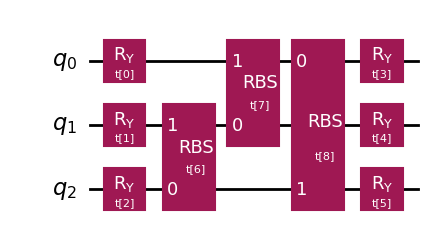

--- RBS-2q.6 (esatto) (6 par) ---


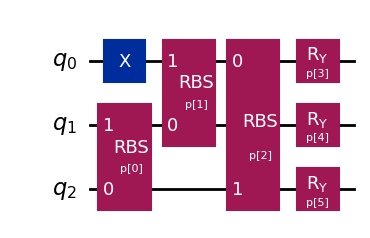

--- W-2q.6 (esatto) -- candidato canonico (6 par) ---


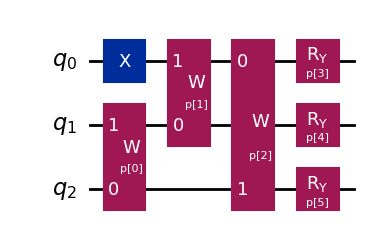

--- RBS-2qC.K1 (ciclico) (6 par) ---


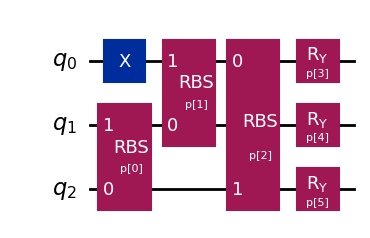

In [6]:
def show(qc, title):
    print(f"--- {title} ({qc.num_parameters} par) ---")
    try:
        display(qc.draw("mpl", style="iqp"))
    except Exception:
        print(qc.draw())

show(ANSATZE["D: Ry-RBS-Ry"], "D: Ry-RBS-Ry")
show(ANSATZE["RBS-2q.6"], "RBS-2q.6 (esatto)")
show(ANSATZE["W-2q.6"], "W-2q.6 (esatto) -- candidato canonico")
show(ANSATZE["RBS-2qC.K1"], "RBS-2qC.K1 (ciclico)")

## 2.1 Selettore interattivo: visualizza un circuito qualsiasi

Menu a tendina su tutte e 15 le varianti, più un toggle per passare dalla
forma compatta (blocchi RBS/$W$ come scatole etichettate) alla vista con
tutti i gate elementari, raggruppati per blocco originale con un riquadro
(`qc.box()`). Se `ipywidgets` non è installato, la cella mostra invece
tutti i circuiti in forma compatta, senza errori.

Esempio di default -- forma compatta:


W-2q.6 -- 6 parametri, 6 gate a due qubit, 13 gate totali


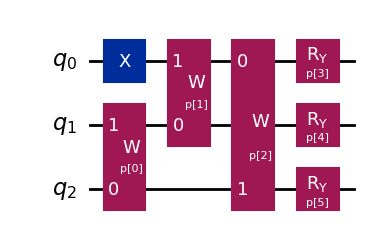


Stesso circuito -- tutti i gate elementari, raggruppati per blocco:
W-2q.6 -- 6 parametri, 6 gate a due qubit, 13 gate totali


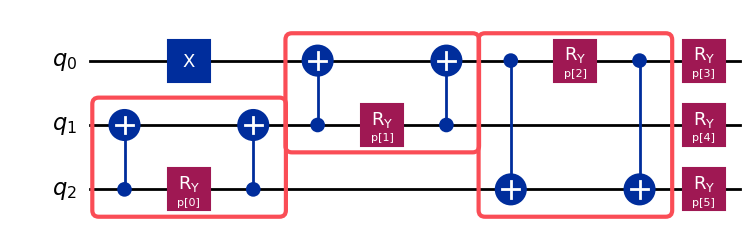


Selettore interattivo (richiede un kernel Jupyter vivo -- non mostra nulla in un viewer statico):


Output()

In [7]:
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output
    HAS_WIDGETS = True
except ImportError:
    HAS_WIDGETS = False

def mostra_circuito(nome, modalita="Forma compatta"):
    qc = ANSATZE[nome]
    ops = qc.decompose().count_ops()
    n_2q = ops.get("cz", 0) + ops.get("cx", 0)
    print(f"{nome} -- {qc.num_parameters} parametri, {n_2q} gate a due qubit, "
          f"{sum(ops.values())} gate totali")
    da_disegnare = ANSATZE[nome] if modalita == "Forma compatta" else ANSATZE_BOXED[nome]
    try:
        display(da_disegnare.draw("mpl", style="iqp"))
    except Exception:
        print(da_disegnare.draw())

print("Esempio di default -- forma compatta:")
mostra_circuito("W-2q.6", "Forma compatta")
print("\nStesso circuito -- tutti i gate elementari, raggruppati per blocco:")
mostra_circuito("W-2q.6", "Tutti i gate")

if HAS_WIDGETS:
    dropdown = widgets.Dropdown(
        options=list(ANSATZE.keys()),
        value="W-2q.6",
        description="Ansatz:",
        style={"description_width": "initial"},
    )
    toggle = widgets.ToggleButtons(
        options=["Forma compatta", "Tutti i gate"],
        value="Forma compatta",
        description="Vista:",
        style={"description_width": "initial"},
    )
    out = widgets.Output()

    def _aggiorna(*_):
        with out:
            clear_output(wait=True)
            mostra_circuito(dropdown.value, toggle.value)

    dropdown.observe(_aggiorna, names="value")
    toggle.observe(_aggiorna, names="value")

    print("\nSelettore interattivo (richiede un kernel Jupyter vivo -- non "
          "mostra nulla in un viewer statico):")
    display(widgets.HBox([dropdown, toggle]), out)
    _aggiorna()
else:
    print("\nipywidgets non disponibile: mostro tutti gli altri circuiti in "
          "forma compatta (senza il toggle).\n")
    for nome in ANSATZE:
        if nome != "W-2q.6":
            mostra_circuito(nome, "Forma compatta")
            print()

## 3. Fidelity per ciascun ansatz — $D=0$ e con DM (Opzione B, $D=0.15$)

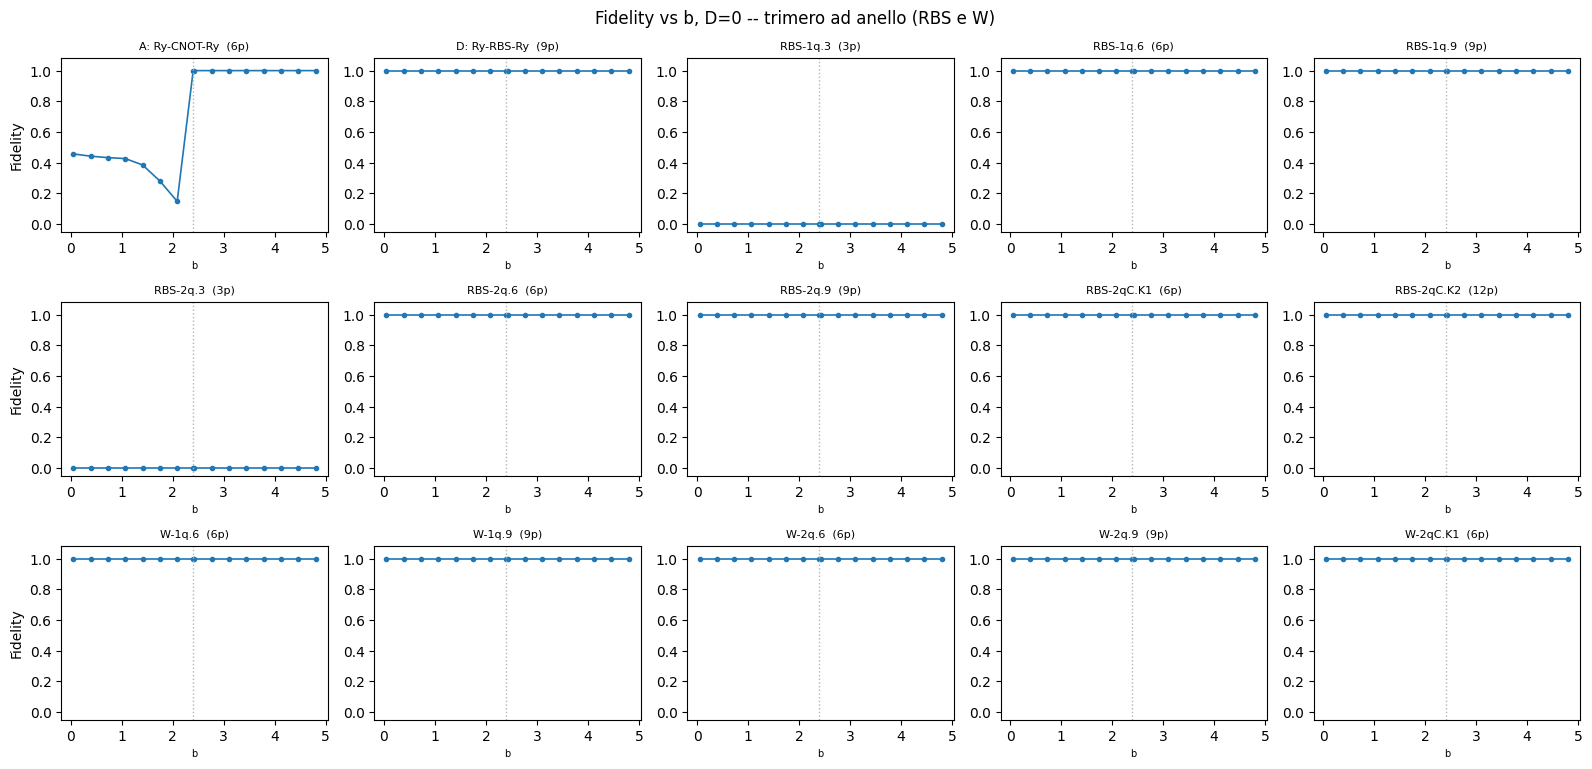

In [8]:
def get_series(tag, name, key="fidelity"):
    return [cache[f"{tag}|{name}|{b}"][key] for b in B_GRID]

def plot_grid(tag, title):
    names = list(ANSATZE.keys())
    ncols, nrows = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 2.6*nrows), squeeze=False)
    for ax, name in zip(axes.flat, names):
        fid = get_series(tag, name)
        npar = ANSATZE[name].num_parameters
        ax.plot(B_GRID, fid, "o-", ms=3, lw=1.2, color="tab:blue")
        ax.axvline(bc, color="0.7", ls=":", lw=1)
        ax.set_ylim(-0.05, 1.08)
        ax.set_title(f"{name}  ({npar}p)", fontsize=8)
        ax.set_xlabel("b", fontsize=7)
    for ax in axes.flat[len(names):]:
        ax.axis("off")
    axes.flat[0].set_ylabel("Fidelity")
    axes.flat[5].set_ylabel("Fidelity")
    axes.flat[10].set_ylabel("Fidelity")
    fig.suptitle(title)
    fig.tight_layout()
    return fig

fig = plot_grid("D0", "Fidelity vs b, D=0 -- trimero ad anello (RBS e W)")
fig.savefig("confronto_ansatz_trimero_anello_fidelity_D0.png", dpi=150)
plt.show()

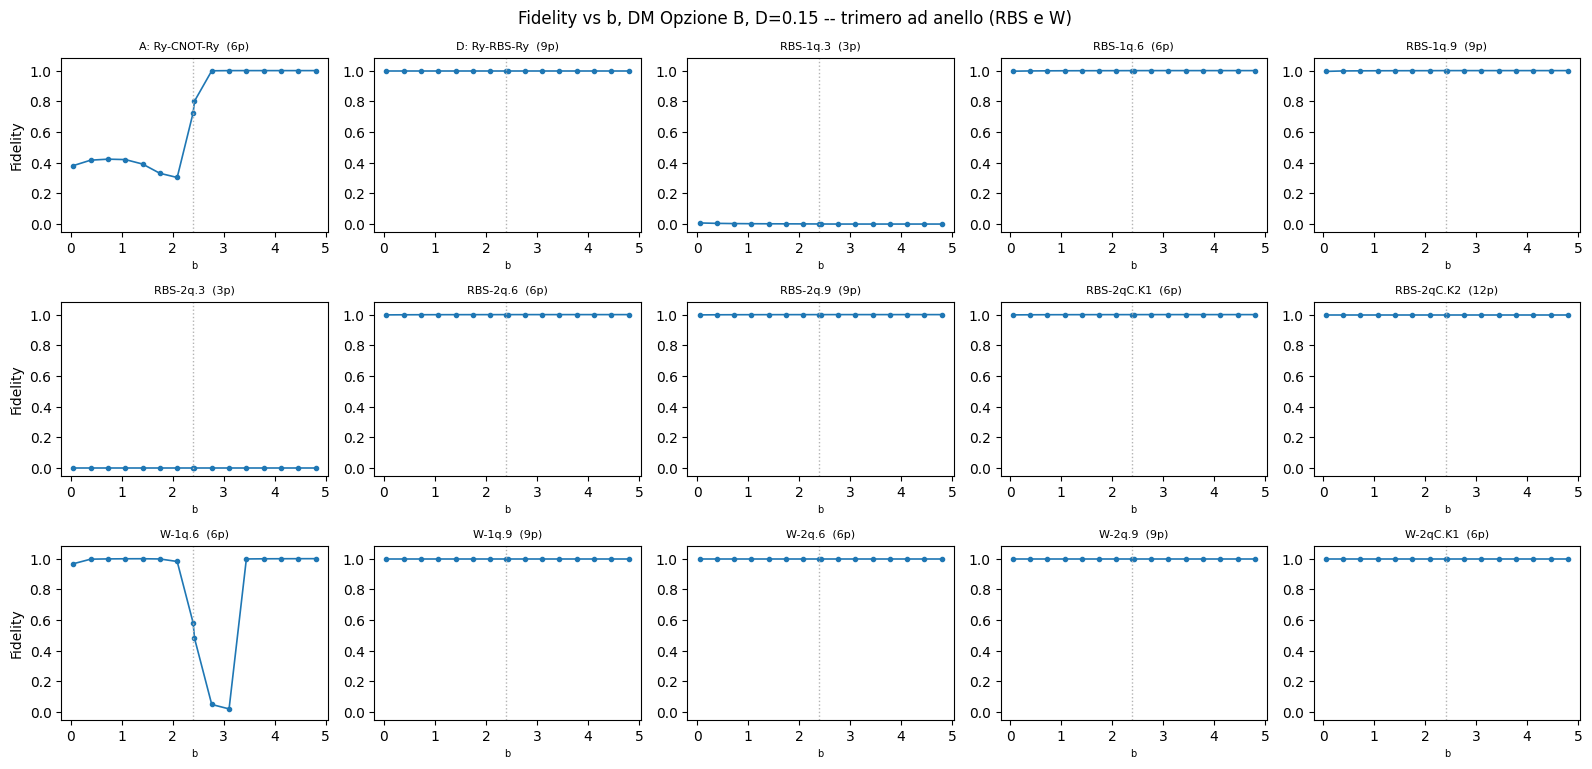

In [9]:
fig = plot_grid("DM", "Fidelity vs b, DM Opzione B, D=0.15 -- trimero ad anello (RBS e W)")
fig.savefig("confronto_ansatz_trimero_anello_fidelity_DM.png", dpi=150)
plt.show()

## 4. Tabelle riassuntive

In [10]:
print(f"{'ansatz':14s} {'par':>4s} | {'D=0 media':>10s} {'D=0 min':>8s} | {'DM media':>9s} {'DM min':>7s}")
print("-"*68)
for name in ANSATZE:
    npar = ANSATZE[name].num_parameters
    fid_d0 = get_series("D0", name)
    fid_dm = get_series("DM", name)
    print(f"{name:14s} {npar:4d} | {np.mean(fid_d0):10.4f} {np.min(fid_d0):8.4f} | "
          f"{np.mean(fid_dm):9.4f} {np.min(fid_dm):7.4f}")

ansatz          par |  D=0 media  D=0 min |  DM media  DM min
--------------------------------------------------------------------
A: Ry-CNOT-Ry     6 |     0.7233   0.1479 |    0.6995  0.3035
D: Ry-RBS-Ry      9 |     1.0000   1.0000 |    1.0000  1.0000
RBS-1q.3          3 |     0.0000   0.0000 |    0.0014  0.0000
RBS-1q.6          6 |     1.0000   1.0000 |    0.9994  0.9962
RBS-1q.9          9 |     1.0000   1.0000 |    0.9993  0.9948
RBS-2q.3          3 |     0.0000   0.0000 |    0.0000 -0.0000
RBS-2q.6          6 |     1.0000   1.0000 |    0.9997  0.9981
RBS-2q.9          9 |     1.0000   1.0000 |    0.9997  0.9981
RBS-2qC.K1        6 |     1.0000   1.0000 |    0.9997  0.9981
RBS-2qC.K2       12 |     1.0000   1.0000 |    1.0000  1.0000
W-1q.6            6 |     1.0000   1.0000 |    0.8166  0.0205
W-1q.9            9 |     1.0000   1.0000 |    1.0000  1.0000
W-2q.6            6 |     1.0000   1.0000 |    1.0000  1.0000
W-2q.9            9 |     1.0000   1.0000 |    1.0000  1.0000
W

In [11]:
# conteggio dei gate a due qubit e totali, dopo decomposizione
print(f"{'ansatz':14s} {'par':>4s} {'2q-gate':>8s} {'tot-gate':>9s}")
print("-"*40)
for name, qc in ANSATZE.items():
    ops = qc.decompose().count_ops()
    n_2q = ops.get("cz", 0) + ops.get("cx", 0)
    n_tot = sum(ops.values())
    print(f"{name:14s} {qc.num_parameters:4d} {n_2q:8d} {n_tot:9d}")

ansatz          par  2q-gate  tot-gate
----------------------------------------
A: Ry-CNOT-Ry     6        3         9
D: Ry-RBS-Ry      9        6        30
RBS-1q.3          3        4        18
RBS-1q.6          6        6        28
RBS-1q.9          9       10        45
RBS-2q.3          3        6        25
RBS-2q.6          6        6        28
RBS-2q.9          9        6        31
RBS-2qC.K1        6        6        28
RBS-2qC.K2       12       12        55
W-1q.6            6        6        13
W-1q.9            9       10        20
W-2q.6            6        6        13
W-2q.9            9        6        16
W-2qC.K1          6        6        13


## 5. Lettura dei risultati

**Ansatz generici (A, D).** `A` (Ry-CNOT-Ry) resta debole ovunque (nessun
meccanismo per raggiungere gli stati corretti, coerente col dimero e la
catena). `D` (Ry-RBS-Ry) raggiunge $\mathcal F=1$ esatto ovunque, sia a
$D=0$ sia con DM -- ma con 9 parametri e 6 gate a due qubit, più costoso
delle famiglie PMA a parità di prestazioni.

**Famiglie 1q e 2q, RBS vs $W$.** A $D=0$ tutte le famiglie con 6+
parametri (sia RBS sia $W$) raggiungono $\mathcal F=1$ esatto. **La
differenza emerge sotto DM**, coerentemente con quanto scoperto in
`analisi_espressivita_PMA_anello.ipynb` al singolo punto $b=b_c$: qui lo
sweep completo conferma se quel risultato si estende a tutto l'asse $b$.

**Costo in gate.** A parità di parametri, i blocchi $W$ non usano
Hadamard: meno della metà dei gate totali dei corrispondenti blocchi RBS
(vedi tabella sopra), a parità di gate a due qubit.

## 6. Cosa portarsi dietro

Combinando fidelity ed economia di gate, il candidato canonico per il
seguito (rumore, Parte 2) è **`W-2q.6`**: nella verifica dedicata di
`analisi_espressivita_PMA_anello.ipynb` raggiunge $\mathcal F=1$ esatto
sotto DM a $b_c$ con 6 parametri e 13 gate totali, dove il corrispondente
`RBS-2q.6` resta bloccato a un tetto strutturale $\approx0.9983$ anche a
9 parametri. Questo notebook estende quella verifica a tutta la griglia
in $b$ (sez. 3-4): se il vantaggio si conferma ovunque, `W-2q.6` sostituisce
`RBS-2q.6`/`PMA-2q.3` come riferimento per i notebook successivi.

**Dettaglio emerso solo con lo sweep completo (non visibile al solo $b=b_c$).** Il crollo di `W-1q.6` non è uniforme: resta a $\mathcal F\approx1$ per $b$ lontano dalla transizione, e **crolla quasi a zero solo in una finestra stretta appena sopra $b_c$** (minimo $\mathcal F=0.0205$ intorno a $b\approx3.1$), poi risale. Coerente fisicamente: è proprio lì che il mescolamento fra i blocchi $A$ e $C$ indotto dal DM è massimo. Il singolo punto testato nell'indagine mirata ($b=b_c=2.4$ esatto, $\mathcal F=0.868$) aveva già segnalato il problema, ma non la sua severità reale un po' più in là sull'asse.

## Nota tecnica

Notebook self-contained: ansatz (RBS e $W$), calcolo VQE e analisi in un
solo file. Unica dipendenza esterna: `trimer_ring_exact.py` (benchmark
esatto, condiviso con tutti gli altri notebook del progetto). La cache
(`trimer_ansatz_sweep_cache_v2.json`) parte da una rimappatura della cache
precedente (nomi `PMA-*` → `RBS-*`) e si estende da sola per i punti $W$
mancanti.

**Ordine corretto rispetto alla versione precedente**: questo notebook
importa la conclusione di `analisi_espressivita_PMA_anello.ipynb`
(candidato `W-2q.6`), non il contrario -- stessa direzione di dipendenza
del dimero (`analisi_rotazioni_PMA.ipynb` → `confronto_ansatz_entangler.ipynb`).